# Importing the libraries

In [1]:
import pandas as pd
from datetime import datetime, timezone
import pytz
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Process the activity data by first reading it, ensuring its cleanliness, and then resampling it as needed.

In [2]:
import pandas as pd

df = pd.read_csv("HUPA0014P.csv", sep=";")

df["time"] = pd.to_datetime(df["time"])
df.set_index("time", inplace=True)

df_steps_hr = df[["heart_rate", "steps"]]

# Rename index
df_steps_hr.index.name = "Timestamp"

df_steps_hr

,heart_rate,steps
Timestamp,,
2018-11-07 16:45:00,71.214286,0.0
2018-11-07 16:50:00,70.156522,0.0
2018-11-07 16:55:00,69.077519,0.0
2018-11-07 17:00:00,69.341270,0.0
2018-11-07 17:05:00,70.663793,0.0
...,...,...
2018-11-20 23:25:00,86.903226,0.0
2018-11-20 23:30:00,86.064516,0.0
2018-11-20 23:35:00,83.923077,18.0


In [3]:
data_activity = df_steps_hr.copy()
data_activity['Activity'] = data_activity['steps'] * data_activity['heart_rate']
data_activity = data_activity.groupby(data_activity.index).mean()
data_activity = data_activity[(data_activity.index.hour >= 6) & (data_activity.index.hour <= 23)]
data_activity.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2893 entries, 2018-11-07 16:45:00 to 2018-11-20 23:45:00
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   heart_rate  2893 non-null   float64
 1   steps       2893 non-null   float64
 2   Activity    2893 non-null   float64
dtypes: float64(3)
memory usage: 90.4 KB


In [4]:
data_activity.describe()

,heart_rate,steps,Activity
count,2893.000000,2893.000000,2893.000000
mean,85.672012,46.875562,4858.118927
std,14.726344,106.355118,11510.442258
min,53.512195,0.000000,0.000000
25%,74.102031,0.000000,0.000000
50%,85.965517,0.000000,0.000000
75%,95.465649,30.000000,2741.064516
max,168.562500,609.000000,78674.511628


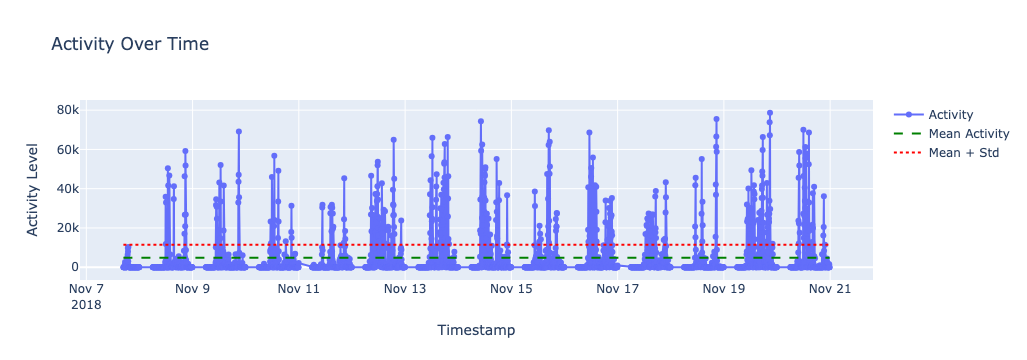

In [5]:
mean_activity = data_activity['Activity'].mean()
std_activity = data_activity['Activity'].std()
fig = go.Figure()
fig.add_trace(go.Scatter(x=data_activity.index, y=data_activity['Activity'], mode='lines + markers', name='Activity'))
fig.add_trace(go.Scatter(
    x=data_activity.index, 
    y=[mean_activity] * len(data_activity), 
    mode='lines', 
    name='Mean Activity',
    line=dict(dash='dash', color='green')
))
fig.add_trace(go.Scatter(
    x=data_activity.index, 
    y=[std_activity] * len(data_activity), 
    mode='lines', 
    name='Mean + Std',
    line=dict(dash='dot', color='red')
))
fig.update_layout(
    title="Activity Over Time",
    xaxis_title="Timestamp",
    yaxis_title="Activity Level",
)
fig.show()

In [6]:
mean_activity = data_activity.Activity.mean()
filtered_data_activity = data_activity[data_activity['Activity'] > mean_activity]
x0 = filtered_data_activity.Activity.min()
x1 = filtered_data_activity.Activity.quantile(0.25)
x2 = filtered_data_activity.Activity.quantile(0.5)
x3 = filtered_data_activity.Activity.quantile(0.75)
x4 = filtered_data_activity.Activity.max()
filtered_data_activity.describe()

,heart_rate,steps,Activity
count,587.000000,587.000000,587.000000
mean,101.787796,212.144804,22202.255710
std,10.987014,145.039201,16487.392911
min,76.964286,32.000000,4870.000000
25%,94.386437,85.000000,8386.027473
50%,100.636364,174.000000,17480.000000
75%,107.927899,303.000000,31872.384170
max,168.562500,609.000000,78674.511628


In [7]:
filtered_data_lows = filtered_data_activity[(filtered_data_activity['Activity'] >= x0) & (filtered_data_activity['Activity'] < x1)]
filtered_data_mediums = filtered_data_activity[(filtered_data_activity['Activity'] >= x1) & (filtered_data_activity['Activity'] < x2)]
filtered_data_highs = filtered_data_activity[(filtered_data_activity['Activity'] >= x2) & (filtered_data_activity['Activity'] < x3)]
filtered_data_very_highs = filtered_data_activity[(filtered_data_activity['Activity'] >= x3) & (filtered_data_activity['Activity'] <= x4)]
filtered_data_lows

,heart_rate,steps,Activity
Timestamp,,,
2018-11-07 18:40:00,94.061728,67.0,6302.135802
2018-11-07 18:50:00,102.931507,78.0,8028.657534
2018-11-08 14:00:00,80.440000,80.0,6435.200000
2018-11-08 17:45:00,78.694444,71.0,5587.305556
2018-11-08 20:35:00,84.954545,58.0,4927.363636
...,...,...,...
2018-11-20 15:50:00,100.448276,54.0,5424.206897
2018-11-20 16:50:00,92.600000,60.0,5556.000000
2018-11-20 20:20:00,95.323529,70.0,6672.647059


# Process the glucose data by first reading it, ensuring its cleanliness, and then resampling it as needed

In [8]:
import pandas as pd

df = pd.read_csv("HUPA0014P.csv", sep=";")

# Convert time
df["time"] = pd.to_datetime(df["time"], errors="coerce")

# Select + rename columns
df_glucose = df[["time", "glucose"]].copy()
df_glucose.rename(columns={"time": "Timestamp", "glucose": "Glucose"}, inplace=True)

# Clean
df_glucose["Glucose"] = pd.to_numeric(df_glucose["Glucose"], errors="coerce")
df_glucose.dropna(inplace=True)

# Set index
df_glucose.set_index("Timestamp", inplace=True)
df_glucose["Glucose"] = df_glucose["Glucose"] / 18.0182
data_glucose = df_glucose.copy()
data_glucose.tail(20)

,Glucose
Timestamp,
2018-11-20 22:10:00,8.639413
2018-11-20 22:15:00,8.546914
2018-11-20 22:20:00,8.528414
2018-11-20 22:25:00,8.509914
2018-11-20 22:30:00,8.491414
2018-11-20 22:35:00,8.750412
2018-11-20 22:40:00,9.009409
2018-11-20 22:45:00,9.268406
2018-11-20 22:50:00,9.693902


In [9]:
data_glucose = data_glucose[data_glucose.index.minute % 15 == 0].copy()

data_glucose.loc[:, 'nextGlucose'] = data_glucose['Glucose'].shift(-1)
data_glucose.loc[:, 'GlucoseChange'] = data_glucose['Glucose'] - data_glucose['nextGlucose']

data_glucose = data_glucose[:-1]

data_glucose = data_glucose.reset_index()

data_glucose = data_glucose[
    (data_glucose['Timestamp'].shift(-1) - data_glucose['Timestamp'])
    .dt.total_seconds() / 60 == 15
]

data_glucose = data_glucose.set_index('Timestamp')

data_glucose = data_glucose.dropna()
data_glucose

,Glucose,nextGlucose,GlucoseChange
Timestamp,,,
2018-11-07 16:45:00,9.157408,9.101908,0.055499
2018-11-07 17:00:00,9.101908,9.046409,0.055499
2018-11-07 17:15:00,9.046409,9.101908,-0.055499
2018-11-07 17:30:00,9.101908,8.879910,0.221998
2018-11-07 17:45:00,8.879910,8.713412,0.166498
...,...,...,...
2018-11-20 22:15:00,8.546914,8.491414,0.055499
2018-11-20 22:30:00,8.491414,9.268406,-0.776992
2018-11-20 22:45:00,9.268406,10.544893,-1.276487


# Merge Glucose with Different Levels of Activity

In [10]:
def process_glucose_changes(filtered_data, data_glucose):
    merged_data = pd.merge(filtered_data, data_glucose, left_index=True, right_index=True, how='inner')
    merged_data = merged_data[merged_data['Glucose'] > merged_data['nextGlucose']]
    merged_data.reset_index(inplace=True)
    return merged_data
actgluco_low = process_glucose_changes(filtered_data_lows, data_glucose)
actgluco_medium = process_glucose_changes(filtered_data_mediums, data_glucose)
actgluco_high = process_glucose_changes(filtered_data_highs, data_glucose)
actgluco_very_high = process_glucose_changes(filtered_data_very_highs, data_glucose)

for name, df in zip(
    ['low', 'medium', 'high', 'very_high'],
    [actgluco_low, actgluco_medium, actgluco_high, actgluco_very_high]
):
    df.to_csv(f'actgluco_{name}.csv', index=False)

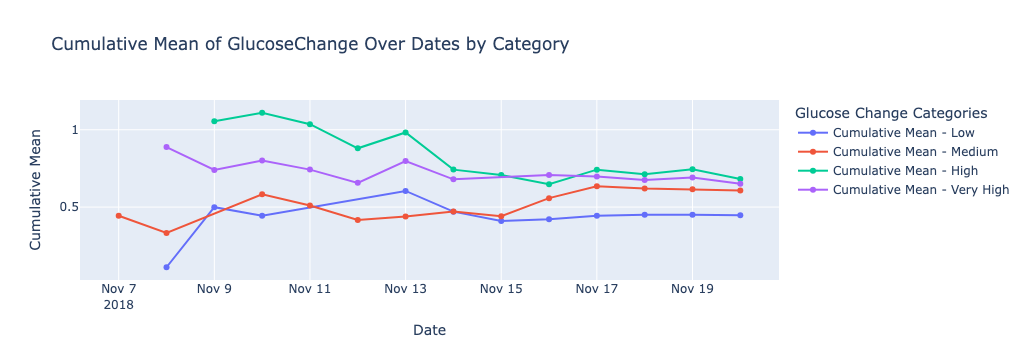

In [11]:
def plot_multiple_cumulative_means(data_dict):
    fig = go.Figure()
    
    for label, data in data_dict.items():
        unique_dates = sorted(data['Timestamp'].dt.date.unique())
        cumulative_means = []
        
        for i in range(len(unique_dates)):
            current_data = data[data['Timestamp'].dt.date <= unique_dates[i]]
            mean = current_data['GlucoseChange'].mean()
            cumulative_means.append(mean)
        
        fig.add_trace(go.Scatter(
            x=unique_dates,
            y=cumulative_means,
            mode='lines+markers',
            name=f'Cumulative Mean - {label}'
        ))
    
    fig.update_layout(
        title="Cumulative Mean of GlucoseChange Over Dates by Category",
        xaxis_title="Date",
        yaxis_title="Cumulative Mean",
        legend_title="Glucose Change Categories"
    )
    
    fig.show()
    
data_dict = {
    "Low": actgluco_low,
    "Medium": actgluco_medium,
    "High": actgluco_high,
    "Very High": actgluco_very_high
}

plot_multiple_cumulative_means(data_dict)

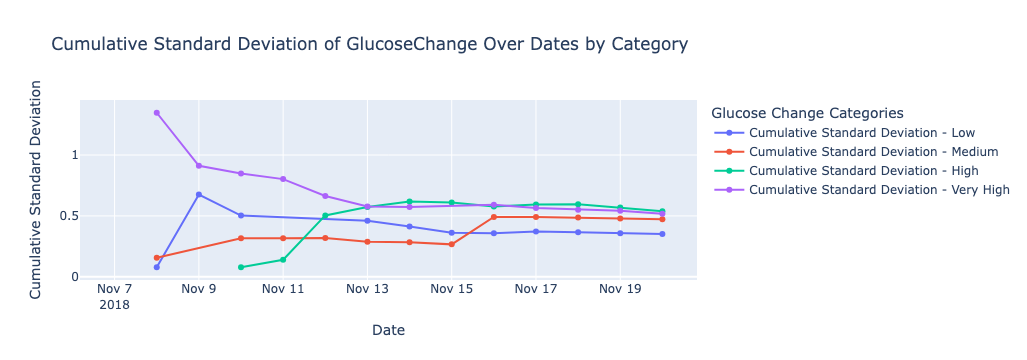

In [12]:
def plot_multiple_cumulative_std(data_dict):
    fig = go.Figure()
    
    for label, data in data_dict.items():
        unique_dates = sorted(data['Timestamp'].dt.date.unique())
        cumulative_std = []
        
        for i in range(len(unique_dates)):
            current_data = data[data['Timestamp'].dt.date <= unique_dates[i]]
            std = current_data['GlucoseChange'].std()
            cumulative_std.append(std)
        
        fig.add_trace(go.Scatter(
            x=unique_dates,
            y=cumulative_std,
            mode='lines+markers',
            name=f'Cumulative Standard Deviation - {label}'
        ))
    
    fig.update_layout(
        title="Cumulative Standard Deviation of GlucoseChange Over Dates by Category",
        xaxis_title="Date",
        yaxis_title="Cumulative Standard Deviation",
        legend_title="Glucose Change Categories"
    )
    
    fig.show()
data_dict = {
    "Low": actgluco_low,
    "Medium": actgluco_medium,
    "High": actgluco_high,
    "Very High": actgluco_very_high
}

plot_multiple_cumulative_std(data_dict)

# Moving Average Window

In [13]:
def mean_std_predict_next_day(filtered_data, category_name, window_size=10):
    filtered_data['Date'] = pd.to_datetime(filtered_data['Timestamp']).dt.date
    unique_days = sorted(filtered_data['Date'].unique())

    results = []

    for i in range(len(unique_days) - window_size):
        window_days = unique_days[i:i + window_size]            
        predict_day_index = i + window_size
        
        if predict_day_index >= len(unique_days):
            break
        
        predict_day = unique_days[predict_day_index]

        window_data = filtered_data[filtered_data['Date'].isin(window_days)]
        next_day_data = filtered_data[filtered_data['Date'] == predict_day]

        if next_day_data.empty:
            continue

        mean_glucose = window_data['GlucoseChange'].mean()
        std_glucose = window_data['GlucoseChange'].std()

        actual_mean_next = next_day_data['GlucoseChange'].mean()
        actual_std_next = next_day_data['GlucoseChange'].std()

        lower_bound = mean_glucose - std_glucose
        upper_bound = mean_glucose + std_glucose

        prediction_status = lower_bound <= actual_mean_next <= upper_bound

        results.append({
            'Category': category_name,
            'Window Start': window_days[0],
            'Window End': window_days[-1],
            'Predicted Mean': mean_glucose,
            'Predicted Standard Deviation': std_glucose,
            'Lower Bound': lower_bound,
            'Upper Bound': upper_bound,
            'Next Day': predict_day,
            'Actual Next Day Mean': actual_mean_next,
            'Actual Next Day Standard Deviation': actual_std_next,
            'Prediction Status': prediction_status
        })

    return pd.DataFrame(results)
window_size = 10

result_df_lows = mean_std_predict_next_day(actgluco_low, 'Lows', window_size)
result_df_mediums = mean_std_predict_next_day(actgluco_medium, 'Mediums', window_size)
result_df_highs = mean_std_predict_next_day(actgluco_high, 'Highs', window_size)
result_df_very_highs = mean_std_predict_next_day(actgluco_very_high, 'Very Highs', window_size)

all_results_df = pd.concat([result_df_lows, result_df_mediums, result_df_highs, result_df_very_highs])

category_order = ['Lows', 'Mediums', 'Highs', 'Very Highs']
all_results_df['Category'] = pd.Categorical(all_results_df['Category'], categories=category_order, ordered=True)

all_results_df.to_csv(f'rolling_window_glucose_prediction.csv', index=False)

grouped_results = all_results_df.groupby('Category', observed=True).agg({'Prediction Status': ['sum', 'count']})
print(grouped_results)

           Prediction Status      
                         sum count
Category                          
Lows                       1     1
Mediums                    3     3
Highs                      2     2
Very Highs                 2     2


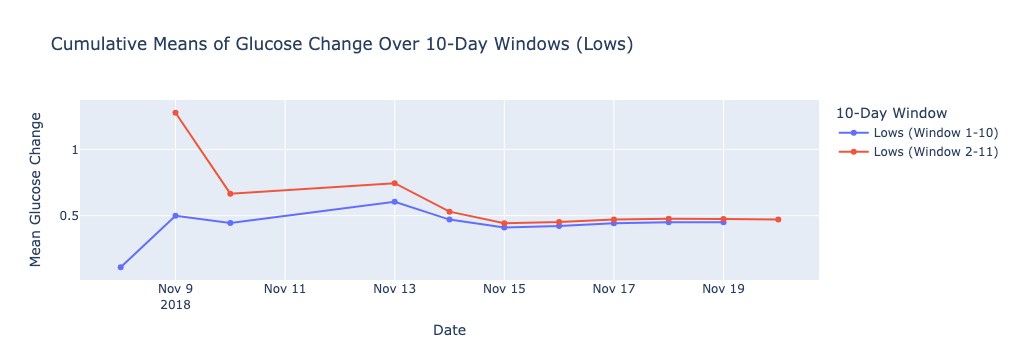

In [14]:
def plot_means_by_inner_window(filtered_data, label):
    filtered_data['Date'] = pd.to_datetime(filtered_data['Timestamp']).dt.date
    unique_days = sorted(filtered_data['Date'].unique())
    
    fig = go.Figure()

    for start_day in range(len(unique_days) - 9):
        dates = []
        means = []
        current_window = unique_days[start_day:start_day + 10]
        cumulative_filtered_data = filtered_data[filtered_data['Date'] >= unique_days[start_day]]
        
        for current_date in current_window:
            cumulative_data = cumulative_filtered_data[cumulative_filtered_data['Date'] <= current_date]['GlucoseChange']
            means.append(cumulative_data.mean() if len(cumulative_data) > 0 else 0)
            dates.append(current_date)
        
        fig.add_trace(go.Scatter(
            x=dates,
            y=means,
            mode='lines+markers',
            name=f"{label} (Window {start_day+1}-{start_day+10})"
        ))

    fig.update_layout(
        title=f'Cumulative Means of Glucose Change Over 10-Day Windows ({label})',
        xaxis_title='Date',
        yaxis_title='Mean Glucose Change',
        legend_title='10-Day Window',
        hovermode='x unified'
    )

    fig.show()

plot_means_by_inner_window(actgluco_low, label='Lows')

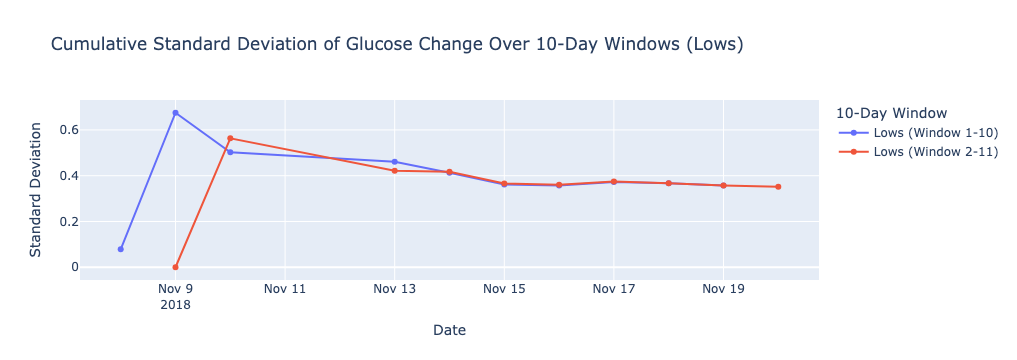

In [15]:
def plot_std_by_inner_window(filtered_data, label):
    filtered_data['Date'] = pd.to_datetime(filtered_data['Timestamp']).dt.date
    unique_days = sorted(filtered_data['Date'].unique())
    
    fig = go.Figure()

    for start_day in range(len(unique_days) - 9):
        dates = []
        std = []
        current_window = unique_days[start_day:start_day + 10]
        cumulative_filtered_data = filtered_data[filtered_data['Date'] >= unique_days[start_day]]
        
        for current_date in current_window:
            cumulative_data = cumulative_filtered_data[cumulative_filtered_data['Date'] <= current_date]['GlucoseChange']
            std.append(cumulative_data.std() if len(cumulative_data) > 1 else 0)
            dates.append(current_date)
        
        fig.add_trace(go.Scatter(
            x=dates,
            y=std,
            mode='lines+markers',
            name=f"{label} (Window {start_day+1}-{start_day+10})"
        ))

    fig.update_layout(
        title=f'Cumulative Standard Deviation of Glucose Change Over 10-Day Windows ({label})',
        xaxis_title='Date',
        yaxis_title='Standard Deviation',
        legend_title='10-Day Window',
        hovermode='x unified'
    )

    fig.show()

plot_std_by_inner_window(actgluco_low, label='Lows')